# Testing with Dask

Tyumen Arayk for model testing

In [36]:
# setup imports
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [37]:
from src.models import *
from src.forcing import load_lumped_forcing_data,generate_lumped_ERA5_forcing
from src.paths import *
from ewatercycle.observation.grdc import get_grdc_data

from scipy.optimize import minimize
import numpy as np

import cma
import seaborn as sns

from dask import delayed, compute
from dask.distributed import Client, progress

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [38]:
shape_name="Tyumen_Aryk_GRDC"
start_date = '1955-01-02T00:00Z'
end_date = '1959-12-31T00:00Z'


forcing = generate_lumped_ERA5_forcing(shape_name, start=start_date,end=end_date)





In [39]:
ERA5_forcing_loaded = load_lumped_forcing_data("Tyumen_Aryk_GRDC", "ERA5", "1955-1959")


grdc_station = get_grdc_data(2316200,
                   '1955-01-02T00:00Z',
                   '1959-12-31T00:00Z',
                   data_home=GRDC/'Daily')
                   

                   
q_obs = grdc_station['streamflow']
years = q_obs['time'].dt.year.values


In [40]:
# CMA-ES test setup
x0_norm = scale(0.5 * (p_min + p_max))  # start in the middle
sigma0 = 0.1  # step size in normalized space

# Define 20 unique seeds
seeds = [
    180988, 214025, 987654, 123456, 654321, 111222, 333444, 555666,
    777888, 999000, 112233, 445566, 778899, 101010, 202020, 303030,
    404040, 505050, 606060, 707070
]

# results = []

# for s in seeds:
#     res = run_cma(
#         seed=s,
#         x0_norm=x0_norm,
#         sigma0=sigma0,
#         objective_fn=objective_safe,
#         popsize=18,
#         maxfevals=360,
#         save_path=f"results/result_seed_{s}.pkl",
#     )
#     results.append(res)

In [41]:
from dask.distributed import Client

# Create a Dask client with 3 workers, 1 thread each, dashboard auto-assigned
client = Client(n_workers=3, threads_per_worker=1, dashboard_address=":0")

# Display client info (clickable dashboard link appears in Jupyter)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42987/status,
Dashboard: http://127.0.0.1:42987/status,Workers: 3
Total threads: 3,Total memory: 31.34 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43945,Workers: 3
Dashboard: http://127.0.0.1:42987/status,Total threads: 3
Started: Just now,Total memory: 31.34 GiB
Comm: tcp://127.0.0.1:44151,Total threads: 1
Dashboard: http://127.0.0.1:38513/status,Memory: 10.45 GiB
Nanny: tcp://127.0.0.1:46825,


In [ ]:
# client = Client()
# futures = client.futures  # all submitted tasks

# # Print active, pending, finished
# for f in futures:
#     print(f.key, f.status)


In [ ]:
# from dask.distributed import Client

# # Assuming you created a client earlier
# client.close()  # closes client and shuts down local cluster/workers


In [ ]:
# from dask.distributed import Client, default_client
# import warnings

# def close_dask():
#     try:
#         # Try to get the current default client
#         client = default_client()
#         print(f"Closing existing Dask client with {len(client.scheduler_info()['workers'])} workers...")
#         client.close()
#         print("Dask client closed successfully.")
#     except ValueError:
#         # No active client
#         print("No active Dask client found.")
#     except Exception as e:
#         warnings.warn(f"Error closing Dask client: {e}")

# # Run the cleanup
# close_dask()

Closing existing Dask client with 3 workers...
Dask client closed successfully.


In [8]:
# from dask import delayed, compute

# objective_fn = make_objective_safe(ERA5_forcing_loaded, q_obs.values, shape_name)
# number_runs = 10
# test_seeds = seeds[:number_runs]

# tasks = [delayed(run_cma)(
#     seed=s,
#     x0_norm=x0_norm,
#     sigma0=sigma0,
#     objective_fn=objective_fn,
#     popsize=10,
#     maxfevals=40,
#     save_folder="results_2/"
# ) for s in test_seeds]

# results = compute(*tasks)
# #print(results)

In [42]:
from dask import delayed
from dask.distributed import progress

objective_fn = make_objective_safe(ERA5_forcing_loaded, q_obs.values, shape_name)
number_runs = 12
test_seeds = seeds[:number_runs]

tasks = [
    delayed(run_cma)(
        cma_seed=s,
        x0_norm=x0_norm,
        sigma0=sigma0,
        objective_fn=objective_fn,
        popsize=16,
        maxfevals=240,
        save_folder="results_6/"
    ) for s in test_seeds
]

# Submit tasks to the cluster
futures = client.compute(tasks)

# Optional: see a live progress bar
progress(futures)

# Gather results when done
results = client.gather(futures)


/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 9 (seed=214025, Thu Jan 29 13:50:39 2026)
(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 9 (seed=333444, Thu Jan 29 13:50:39 2026)
(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 9 (seed=111222, Thu Jan 29 13:50:39 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     16 6.295899796855957e-01 1.0e+00 1.03e-01  1e-01  1e-01 2:09.5
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     16 6.601609741565484e-01 1.0e+00 1.03e-01  1e-01  1e-01 2:11.2
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     16 6.601609741565484e-01 1.0e+00 1.02e-01  1e-01  1e-01 2:13.3
    2     32 6.357629477984038e-01 1.3e+00 1.24e-01  1e-01  1e-01 4:19.0
    2     32 6.731615458040969e-01 1.3e+00 1.13e-01  1e-01  1e-01 4:21.2
    2     32 6.819286837169997e-01 1.3e+00 1.03e-01  1e-01  1e-01 4:26.3
    3     48 6.314705021075060e-01 1.4e+00 1.51e-01  1e-01  2e-01 6:30.1


In [43]:
# Convert results (list of dicts) to a nice table
df_results = pd.DataFrame(results)

# Optional: reorder columns
df_results = df_results[["seed", "best_f", "best_x", "nfev"]]

# Display nicely
df_results

,seed,best_f,best_x,nfev
0,180988,0.442995,"[0.3572730869109299, 0.38865302900554505, 0.74...",256
1,214025,0.449155,"[0.11920520827303077, 0.9088787574464574, 0.89...",256
2,987654,0.469374,"[0.7647224563513757, 0.4847941961539391, 0.725...",256
3,123456,0.437355,"[0.008904469250174438, 0.3421991528273204, 0.8...",256
4,654321,0.474000,"[0.9902707537288017, 0.4636769506671247, 0.944...",256
5,111222,0.449155,"[0.15473423085040683, 0.40661363223179414, 0.6...",256
6,333444,0.495196,"[0.5865002940839766, 0.18717735402878224, 0.95...",256
7,555666,0.453996,"[0.18204587693468818, 0.3278799224748301, 0.57...",256
8,777888,0.447414,"[0.10212910841400236, 0.313502144960338, 0.674...",256
9,999000,0.483642,"[0.4063582843454798, 0.5810128606485535, 0.876...",256


In [44]:
import pickle
from pathlib import Path

results_folder = Path("results_5")
result_files = list(results_folder.glob("result_seed_*.pkl"))

loaded_results = []
for f in result_files:
    with open(f, "rb") as file:
        res = pickle.load(file)
        loaded_results.append(res)

# Example: print best objective per seed
for r in loaded_results:
    print(f"Seed {r['seed']}: best_f = {r['best_f']}, nfev = {r['nfev']}")


Seed 654321: best_f = 0.17191763464028345, nfev = 336
Seed 445566: best_f = 0.19949317983489395, nfev = 336
Seed 111222: best_f = 0.18266575766731064, nfev = 336
Seed 214025: best_f = 0.1774908250283217, nfev = 336
Seed 112233: best_f = 0.17496212376385142, nfev = 336
Seed 987654: best_f = 0.19312110455840456, nfev = 336
Seed 180988: best_f = 0.18076396819507898, nfev = 336
Seed 555666: best_f = 0.17093738634993197, nfev = 336
Seed 123456: best_f = 0.17459049481278965, nfev = 336
Seed 999000: best_f = 0.19603113310254358, nfev = 336
Seed 777888: best_f = 0.17909213433566995, nfev = 336
Seed 333444: best_f = 0.1751420671288759, nfev = 336


In [45]:
best_params_list = []

for run_idx, run in enumerate(results):
    seed = run['seed']
    history = run['history']
    
    # find the best evaluation by objective value
    best_idx = np.argmin(history['objective'])
    
    best_theta_phys = history['theta_phys'][best_idx]
    best_obj = history['objective'][best_idx]
    best_nse = history['nse'][best_idx]
    best_kge = history['kge'][best_idx]
    best_vol_err = history['vol_err'][best_idx]
    
    row = {
        'seed': seed,
        'best_eval': best_idx + 1,
        'objective': best_obj,
        'nse': best_nse,
        'kge': best_kge,
        'vol_err': best_vol_err
    }
    
    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th
    
    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

,seed,best_eval,objective,nse,kge,vol_err,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
0,180988,249,0.442995,0.025473,0.560219,0.046757,8.931827,0.510922,603.158537,2.144487,0.297854,4.473814,0.010794,0.008425,0.773455
1,214025,227,0.449155,0.042918,0.562157,0.076694,2.980130,0.927103,718.652707,3.480005,0.298566,6.605215,0.015031,0.009856,0.483329
2,987654,151,0.469374,-0.056878,0.526743,0.025835,19.118061,0.587835,591.411244,2.242160,0.273709,4.606868,0.010042,0.004775,0.796755
3,123456,240,0.437355,0.007276,0.547050,0.009131,0.222612,0.473759,721.898890,1.939276,0.283583,7.902570,0.010001,0.005879,0.790641
4,654321,243,0.474000,-0.094149,0.515945,0.001348,24.756769,0.570942,757.669225,2.410294,0.293884,7.298662,0.010716,0.007979,0.696877
5,111222,226,0.449155,0.042918,0.562157,0.076694,3.868356,0.525291,565.750134,2.369541,0.283991,7.683474,0.010133,0.008807,0.765527
6,333444,218,0.495196,-0.058446,0.527609,0.089862,14.662507,0.349742,769.543757,1.468473,0.226732,7.944097,0.011176,0.005954,0.609250
7,555666,151,0.453996,-0.019488,0.545705,0.029652,4.551147,0.462304,479.533019,2.158657,0.298466,8.726202,0.010158,0.008782,0.724832
8,777888,200,0.447414,-0.010107,0.548878,0.022615,2.553228,0.450802,552.676791,1.975581,0.257980,5.146584,0.010313,0.008761,0.751603
9,999000,178,0.483642,-0.099870,0.514915,0.020389,10.158957,0.664810,705.893681,2.571798,0.297857,4.932924,0.012296,0.007216,0.785039


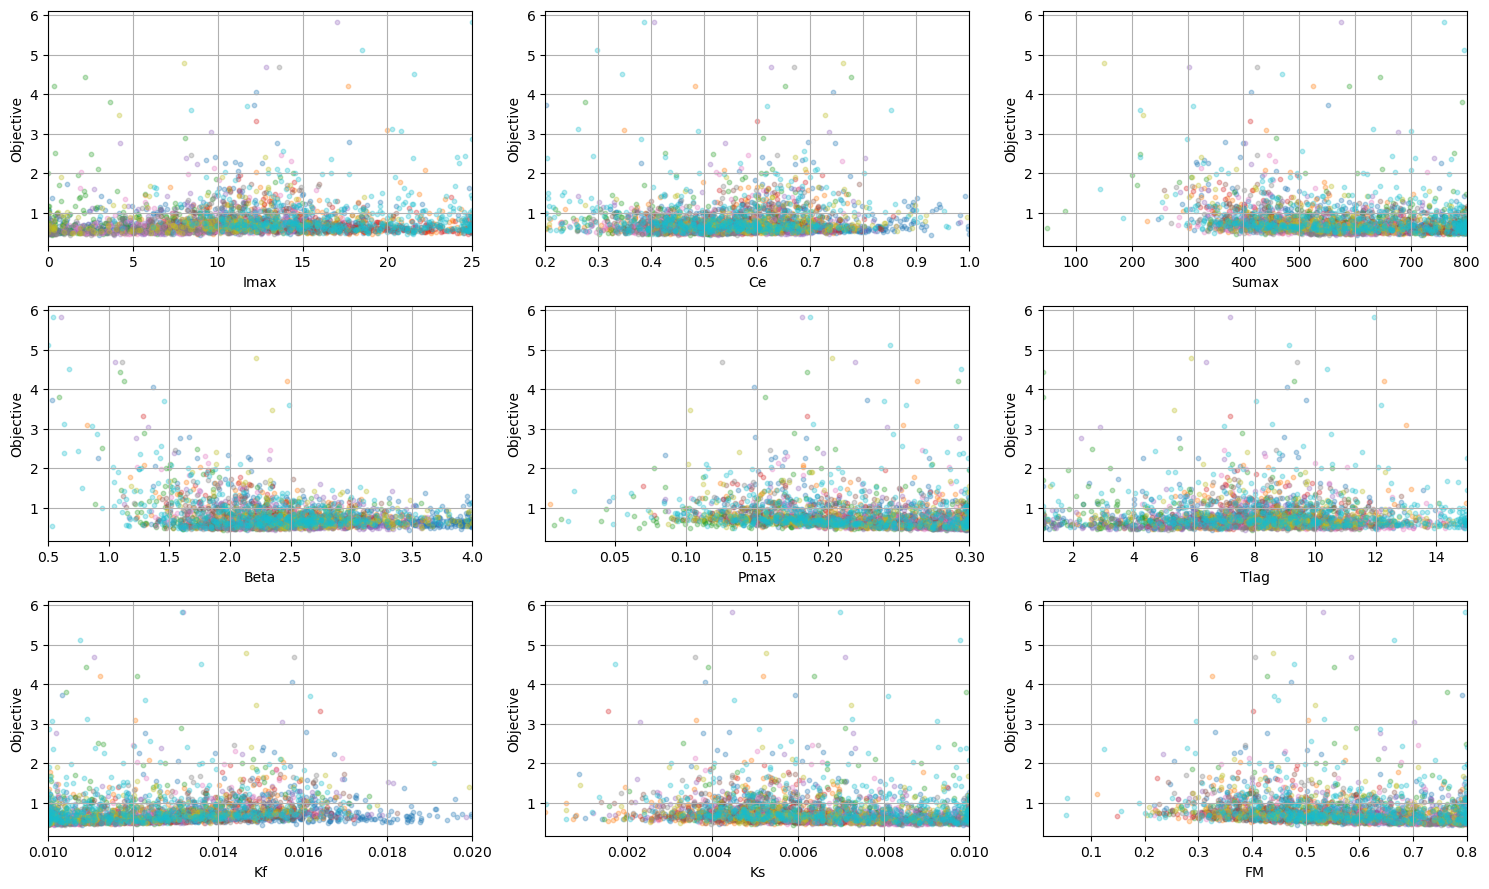

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(results):
    hist = res_seed['history']
    df = pd.DataFrame(hist)
    df['seed'] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)

n_params = len(p_min)  # 9
seeds = history_df['seed'].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i in range(n_params):
    ax = axes[i]
    
    for seed, color in zip(seeds, colors):
        theta_array = np.stack(history_df.loc[history_df['seed']==seed, 'theta_phys'].values)
        obj_array = history_df.loc[history_df['seed']==seed, 'objective'].values
        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.3, s=10)
        ax.set_xlabel(parameter_names[i])
    
    ax.set_ylabel("Objective")
    #ax.set_title()
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

# remove empty axes
for j in range(n_params, len(axes)):
    fig.delaxes(axes[j])


#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


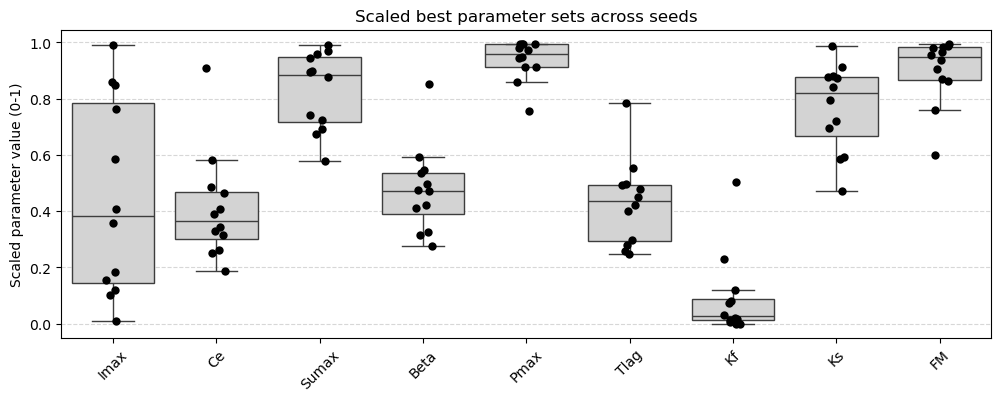

In [47]:
# Parameter columns
param_cols = ["Imax","Ce","Sumax","Beta","Pmax","Tlag","Kf","Ks","FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), 
                                columns=param_cols)


plt.figure(figsize=(12,4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(data=scaled_params_df, color='lightgray', fliersize=0)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color='black', jitter=True, size=6, marker='o')  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [48]:
from dask.distributed import Client

# Assuming you created a client earlier
client.close()  # closes client and shuts down local cluster/workers